In [11]:
# imports

import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [12]:

df = pd.DataFrame(columns=["Job Name", "Slurm Job ID", "Slurm Nodes", "Slurm Node Count", "Slurm NTASKS", "Slurm CPUs per Task", "Slurm Memory per Node", "Slurm Time Limit", "Slurm Partition", "Slurm Account", "INIT_MODE", "RADIUS", "INIT_DEPTH", "TOTAL_STEPS", "SAVE_EVERY", "TARGET_WIDTH", "TARGET_HEIGHT", "CHUNK_SIZE", "MPI_RANKS", "IO_MODE", "MPI_SYNC_MODE", "RANK_GRID_X", "RANK_GRID_Z", "OVERWRITE_OUTPUT", "SKIP_RENDERING", "SKIP_COMPILE", "FFMPEG_THREADS", "RENDER_CPUS", "REDUCED_HEIGHT", "HEIGHT_MIN", "Preparation (s)", "Compilation (s)", "Solving (s)", "Top view rendering (s)", "Slice full height rendering (s)", "Slice reduced height rendering (s)", "Top view video (s)", "Slice full height video (s)", "Combined video 1:1 (s)", "Combined video 16:9 (s)", "Total (s)"])

for file in os.listdir("/hpcwork/thes2181/mini_app/"):
    # check if file is a directory
    if os.path.isdir(os.path.join("/hpcwork/thes2181/mini_app/", file)):
        #circle_r120_d2000_s1000000_triangular_2160x1080_c23mm_16n_96t_1c__parallel_hdf5_none_ts3
        if "triangular" in file and "d2000" in file and "s1000000" in file:
            info_file = os.path.join(os.path.join("/hpcwork/thes2181/mini_app/", file), "timing_and_parameters.txt")
            if os.path.isfile(info_file):
                
                # We want to extract all the information from the info_file and add it to the DataFrame df
                row_data = {}
                
                #row_data["Total Steps"] = re.search(r'_s(\d+)_', file).group(1)
                
                with open(info_file, 'r') as f:
                    for line in f:
                        line = line.strip()
                        if "Job Name:" in line:
                            #Job Name: circle_r120_d2000.0_s1000000_2160x1080_c23mm_16n_96t_1c__rank0_gather_none
                            # the _16n_ here indicates 16 nodes, we want to extract that and put it in the Slurm Node Count column
                            row_data["Slurm Node Count"] = re.search(r'_(\d+)n_', line).group(1)
                        if ':' in line and line and not line.startswith('Parameters') and not line.startswith('Timings'):
                            key, value = line.split(':', 1)
                            key = key.strip()
                            value = value.strip()
                            
                            # Map timing keys to column names with (s) suffix
                            if key in ["Preparation", "Compilation", "Solving", "Top view rendering", 
                                       "Slice full height rendering", "Slice reduced height rendering",
                                       "Top view video", "Slice full height video", "Combined video 1:1", 
                                       "Combined video 16:9", "Total"]:
                                col_name = f"{key} (s)"
                            else:
                                col_name = key
                            
                            row_data[col_name] = value
                
                # Add the row to the DataFrame
                df = pd.concat([df, pd.DataFrame([row_data])], ignore_index=True)

    # Print the DataFrame
df["Total Cores"] = df["Slurm Node Count"].astype(int) * df["Slurm NTASKS"].astype(int) * df["Slurm CPUs per Task"].astype(int) 

df["Solving time per step (s)"] = df["Solving (s)"].astype(float) / df["TOTAL_STEPS"].astype(float)

# we create 3 splits of the data, one for nodes=1, one for ntasks=96 and for ntasks>1
df_nodes_1 = df[df["Slurm Node Count"] == "1"]
df_ntasks_96 = df[df["Slurm NTASKS"] == "96"]
df_ntasks_gt_1 = df[(df["Slurm NTASKS"] > "1") & (df["Slurm NTASKS"] < "96")]

dfs = [df_nodes_1, df_ntasks_96, df_ntasks_gt_1]
df_labels = ["Nodes = 1", "NTASKS = 96", " 1 < NTASKS < 96"]

print(df)

                                             Job Name Slurm Job ID  \
0   circle_r120_d2000_s1000000_triangular_2160x108...     65422065   
1   circle_r120_d2000_s1000000_triangular_2160x108...     65406758   
2   circle_r120_d2000_s1000000_triangular_2160x108...     65422083   
3   circle_r120_d2000_s1000000_triangular_2160x108...     65422067   
4   circle_r120_d2000_s1000000_triangular_2160x108...     65422071   
5   circle_r120_d2000_s1000000_triangular_2160x108...     65422081   
6   circle_r120_d2000_s1000000_triangular_2160x108...     65422064   
7   circle_r120_d2000_s1000000_triangular_2160x108...     65406764   
8   circle_r120_d2000_s1000000_triangular_2160x108...     65406765   
9   circle_r120_d2000_s1000000_triangular_2160x108...     65406762   
10  circle_r120_d2000_s1000000_triangular_2160x108...     65422075   
11  circle_r120_d2000_s1000000_triangular_2160x108...     65422080   
12  circle_r120_d2000_s1000000_triangular_2160x108...     65422068   
13  circle_r120_d200

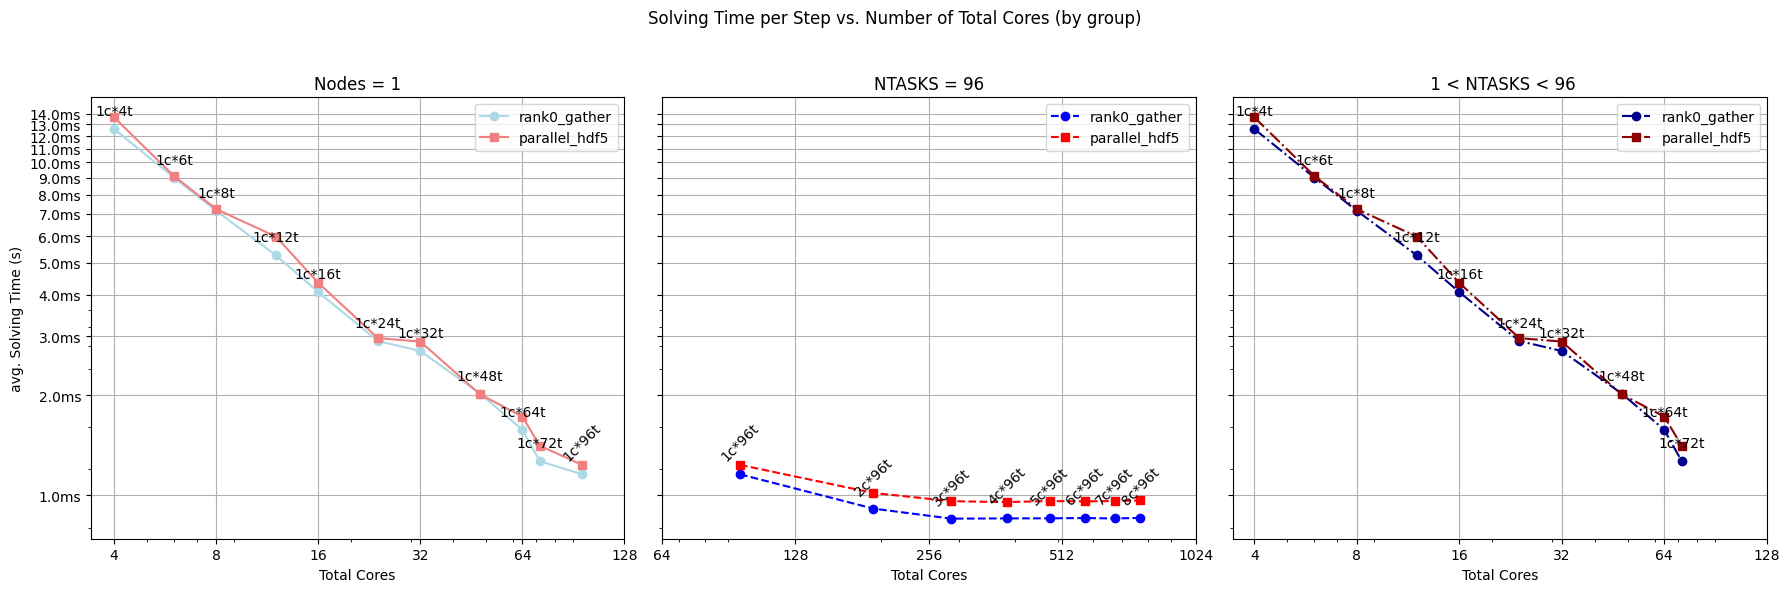

Solving times:
Nodes = 1 (22 runs):
  parallel_hdf5: 0.010862 s
  rank0_gather: 0.002891 s
  rank0_gather: 0.010188 s
  rank0_gather: 0.006783 s
  rank0_gather: 0.003166 s
  rank0_gather: 0.013141 s
  rank0_gather: 0.003932 s
  parallel_hdf5: 0.003522 s
  parallel_hdf5: 0.007412 s
  rank0_gather: 0.005051 s
  parallel_hdf5: 0.014964 s
  parallel_hdf5: 0.018089 s
  parallel_hdf5: 0.007239 s
  rank0_gather: 0.01789 s
  parallel_hdf5: 0.004307 s
  parallel_hdf5: 0.034125 s
  rank0_gather: 0.022514 s
  parallel_hdf5: 0.005025 s
  rank0_gather: 0.03148 s
  parallel_hdf5: 0.022756 s
  rank0_gather: 0.007268 s
  parallel_hdf5: 0.003086 s
NTASKS = 96 (16 runs):
  parallel_hdf5: 0.002385 s
  rank0_gather: 0.002891 s
  parallel_hdf5: 0.002403 s
  rank0_gather: 0.00213 s
  parallel_hdf5: 0.002396 s
  rank0_gather: 0.002136 s
  parallel_hdf5: 0.0024 s
  rank0_gather: 0.002132 s
  parallel_hdf5: 0.002412 s
  parallel_hdf5: 0.002541 s
  rank0_gather: 0.002138 s
  rank0_gather: 0.00228 s
  parallel_h

In [67]:
# Let's plot the solving time on the y-axis and the amount of nodes on the x-axis
# Separate subplots for each IO_MODE and TOTAL_STEPS group
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Define colors for IO_MODE and line styles for TOTAL_STEPS
colors = ['lightblue', 'lightcoral', 'blue', 'red', 'darkblue', 'darkred']
line_styles = ['-', '--', '-.', ':']

for idx, (df_split, label) in enumerate(zip(dfs, df_labels)):
    ax = axes[idx]
    line_style = line_styles[idx % len(line_styles)]

    # Filter for rank0_gather
    rank0_gather = df_split[(df_split["IO_MODE"] == "rank0_gather")].copy()
    rank0_gather["Slurm Node Count"] = pd.to_numeric(rank0_gather["Slurm Node Count"], errors='coerce')
    rank0_gather["Solving (s)"] = pd.to_numeric(rank0_gather["Solving (s)"] , errors='coerce')
    rank0_gather = rank0_gather.sort_values("Total Cores")

    if len(rank0_gather) > 0:
        ax.plot(rank0_gather["Total Cores"], rank0_gather["Solving time per step (s)"], 
                color=colors[(2*idx) % len(colors)], linestyle=line_style, marker='o', label='rank0_gather')

    # Filter for parallel_hdf5
    parallel_hdf5 = df_split[(df_split["IO_MODE"] == "parallel_hdf5")].copy()
    parallel_hdf5["Slurm Node Count"] = pd.to_numeric(parallel_hdf5["Slurm Node Count"], errors='coerce')
    parallel_hdf5["Solving (s)"] = pd.to_numeric(parallel_hdf5["Solving (s)"] , errors='coerce')
    parallel_hdf5 = parallel_hdf5.sort_values("Total Cores")

    if len(parallel_hdf5) > 0:
        ax.plot(parallel_hdf5["Total Cores"], parallel_hdf5["Solving time per step (s)"], 
                color=colors[(1 + 2 * idx) % len(colors)], linestyle=line_style, marker='s', label='parallel_hdf5')

    ax.set_title(label)
    ax.set_xlabel("Total Cores")
    ax.set_xscale('log')
    ax.set_yscale('log')
    yscale = 400
    ax.set_yticks([x/yscale for x in range(1, 15)])
    ax.set_yticklabels([f"{x*yscale:.1f}ms" for x in ax.get_yticks()])
    import math
    ax.set_xticks([2**i for i in range(int(math.log2(min(rank0_gather['Total Cores'].min(), parallel_hdf5['Total Cores'].min()))), int(math.ceil(math.log2(max(rank0_gather['Total Cores'].max(), parallel_hdf5['Total Cores'].max())))) + 1)])
    ax.set_xticklabels([f"{2**i}" for i in range(int(math.log2(min(rank0_gather['Total Cores'].min(), parallel_hdf5['Total Cores'].min()))), int(math.ceil(math.log2(max(rank0_gather['Total Cores'].max(), parallel_hdf5['Total Cores'].max())))) + 1)])
    for row in list(rank0_gather.iterrows()): # + list(parallel_hdf5.iterrows()):
        y = 10 if row[1]['IO_MODE'] == "rank0_gather" else -25
        ax.annotate(f"{row[1]['Slurm Node Count']}c*{row[1]['Slurm NTASKS']}t", (row[1]['Total Cores'], row[1]['Solving time per step (s)']), textcoords="offset points", xytext=(0,y), ha='center', rotation=45 if row[1]['Slurm NTASKS'] == "96" else 0)
    ax.grid()
    ax.legend()

axes[0].set_ylabel("avg. Solving Time (s)")
fig.suptitle("Solving Time per Step vs. Number of Total Cores (by group)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# print solving times
print("Solving times:")
for df_split, label in zip(dfs, df_labels):
    print(f"{label} ({len(df_split)} runs):")
    for _, row in df_split.iterrows():
        print(f"  {row['IO_MODE']}: {row['Solving time per step (s)']} s")

/tmp/ro092286/login23-g-1_365092/ipykernel_467852/1927285376.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_split["Solving Time per (Step*Core)"] = df_split["Solving time per step (s)"] * df_split["Total Cores"]


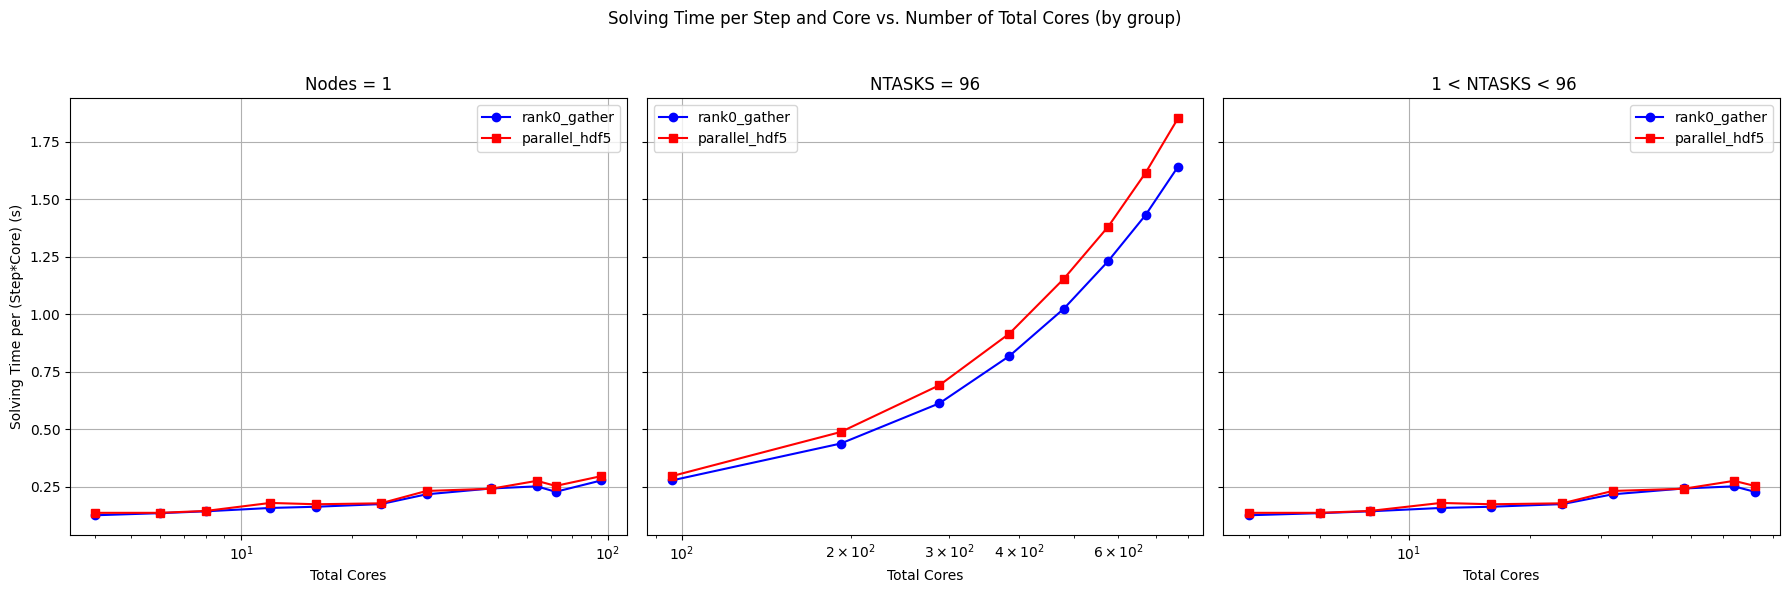

Relative increase in solving time per step and core from rank0_gather to parallel_hdf5 compared to using 1 node and 1 task:
rank0_gather 1 node 4 tasks: 0.125920 s
parallel_hdf5 1 node 4 tasks: 0.136500 s
Solving [rank0_gather, 1, 96]: 2.20x n1t4
Solving [rank0_gather, 1, 16]: 1.29x n1t4
Solving [rank0_gather, 1, 32]: 1.72x n1t4
Solving [rank0_gather, 1, 72]: 1.81x n1t4
Solving [rank0_gather, 1, 12]: 1.25x n1t4
Solving [rank0_gather, 1, 64]: 2.00x n1t4
Solving [rank0_gather, 1, 48]: 1.93x n1t4
Solving [rank0_gather, 1, 8]: 1.14x n1t4
Solving [rank0_gather, 1, 6]: 1.07x n1t4
Solving [rank0_gather, 1, 4]: 1.00x n1t4
Solving [rank0_gather, 1, 24]: 1.39x n1t4
Nodes = 1: 8.40% increase from rank0_gather to parallel_hdf5
Solving [rank0_gather, 1, 96]: 2.20x n1t4
Solving [rank0_gather, 7, 96]: 11.37x n1t4
Solving [rank0_gather, 6, 96]: 9.77x n1t4
Solving [rank0_gather, 5, 96]: 8.13x n1t4
Solving [rank0_gather, 8, 96]: 13.04x n1t4
Solving [rank0_gather, 2, 96]: 3.48x n1t4
Solving [rank0_gather

In [88]:
# Let's plot the solving time on the y-axis and the amount of nodes on the x-axis
# Separate subplots for each split
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

df["Solving Time per (Step*Core)"] = df["Solving time per step (s)"] * df["Total Cores"]
for idx, (df_split, label) in enumerate(zip(dfs, df_labels)):
    df_split["Solving Time per (Step*Core)"] = df_split["Solving time per step (s)"] * df_split["Total Cores"]

# Define colors for IO_MODE and line styles for TOTAL_STEPS
colors = {'rank0_gather': 'blue', 'parallel_hdf5': 'red'}
line_styles = ['-', '--', '-.', ':']

for idx, (df_split, label) in enumerate(zip(dfs, df_labels)):
    ax = axes[idx]
    
    # Get unique TOTAL_STEPS values for this split
    total_steps_values = df_split["TOTAL_STEPS"].unique()
    
    # Plot lines for each TOTAL_STEPS in this split
    for ts_idx, ts in enumerate(sorted(total_steps_values)):
        line_style = line_styles[ts_idx % len(line_styles)]
        
        # Filter for rank0_gather with this TOTAL_STEPS
        rank0_gather = df_split[(df_split["IO_MODE"] == "rank0_gather") & (df_split["TOTAL_STEPS"] == ts)].copy()
        rank0_gather = rank0_gather.sort_values("Total Cores")
        
        if len(rank0_gather) > 0:
            ax.plot(rank0_gather["Total Cores"], rank0_gather["Solving Time per (Step*Core)"], 
                    color='blue', linestyle=line_style, marker='o', label=f'rank0_gather')
        
        # Filter for parallel_hdf5 with this TOTAL_STEPS
        parallel_hdf5 = df_split[(df_split["IO_MODE"] == "parallel_hdf5") & (df_split["TOTAL_STEPS"] == ts)].copy()
        parallel_hdf5 = parallel_hdf5.sort_values("Total Cores")
        
        if len(parallel_hdf5) > 0:
            ax.plot(parallel_hdf5["Total Cores"], parallel_hdf5["Solving Time per (Step*Core)"], 
                    color='red', linestyle=line_style, marker='s', label=f'parallel_hdf5')
    
    ax.set_title(label)
    ax.set_xlabel("Total Cores")
    ax.set_xscale('log')
    ax.grid()
    ax.legend()

axes[0].set_ylabel("Solving Time per (Step*Core) (s)")
fig.suptitle("Solving Time per Step and Core vs. Number of Total Cores (by group)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Let's print the relative increase in solving time per step and core from rank0_gather to parallel_hdf5 compared to using 1 node and 1 task
print("Relative increase in solving time per step and core from rank0_gather to parallel_hdf5 compared to using 1 node and 1 task:")
rank0_gather_1n4t_time = df[(df["IO_MODE"] == "rank0_gather") & 
                             (pd.to_numeric(df["Slurm Node Count"], errors='coerce') == 1) & 
                             (pd.to_numeric(df["Slurm NTASKS"], errors='coerce') == 4)]["Solving Time per (Step*Core)"].values
parallel_hdf5_1n4t_time = df[(df["IO_MODE"] == "parallel_hdf5") & 
                             (pd.to_numeric(df["Slurm Node Count"], errors='coerce') == 1) & 
                             (pd.to_numeric(df["Slurm NTASKS"], errors='coerce') == 4)]["Solving Time per (Step*Core)"].values
print(f"rank0_gather 1 node 4 tasks: {rank0_gather_1n4t_time[0]:.6f} s")
print(f"parallel_hdf5 1 node 4 tasks: {parallel_hdf5_1n4t_time[0]:.6f} s")
for df_split, label in zip(dfs, df_labels):
    for _, row in df_split.iterrows():
        if row.get("IO_MODE") == "rank0_gather":
            stpc = row.get("Solving Time per (Step*Core)")
            if pd.notnull(stpc) and len(rank0_gather_1n4t_time) > 0:
                print(f"Solving [{row.get('IO_MODE')}, {row.get('Slurm Node Count')}, {row.get('Slurm NTASKS')}]: {stpc / rank0_gather_1n4t_time[0]:.2f}x n1t4")
            else:
                print(f"Solving [{row.get('IO_MODE')}, {row.get('Slurm Node Count')}, {row.get('Slurm NTASKS')}]: N/A")
    
    if len(rank0_gather_1n4t_time) > 0 and len(parallel_hdf5_1n4t_time) > 0:
        rank0_time = rank0_gather_1n4t_time[0]
        parallel_time = parallel_hdf5_1n4t_time[0]
        relative_increase = (parallel_time - rank0_time) / rank0_time * 100
        print(f"{label}: {relative_increase:.2f}% increase from rank0_gather to parallel_hdf5")
